#**Importing Libraries**

In [ ]:
import torch

In [ ]:
torch.__version__

'2.11.0+cpu'

Not importing the AmazonReviewFull dataset from ```torchtext``` because **PyTorch** and ```torchtext``` are no longer very compatible, leading to import issues (development of torchtext has been paused).

(Saying cause I tried it)

Instead we make use of the same dataset, but from **HuggingFace**.



In [ ]:
!pip install datasets

In [ ]:
import datasets
datasets.__version__

'4.0.0'

The already installed version of the HuggingFace ```datasets``` library cannot run custom script(in this case called Amazon-Review-2023.py), and hence load_dataset() does not work in this dataset.

We can try downgrading the ```datasets``` version but that will lead to more compatibility issues downstream, hence not advisable.

Secondly, the parquet files are not made use of because we will have to pick on category of products/ loop through multiple files and manualy handle the rating columns as ML labels(distracting us from our main goal of NLP).

So, we move to another dataset, the **yelp_review_full** dataset.

Link: [Yelp/yelp_review_full](https://huggingface.co/datasets/Yelp/yelp_review_full)

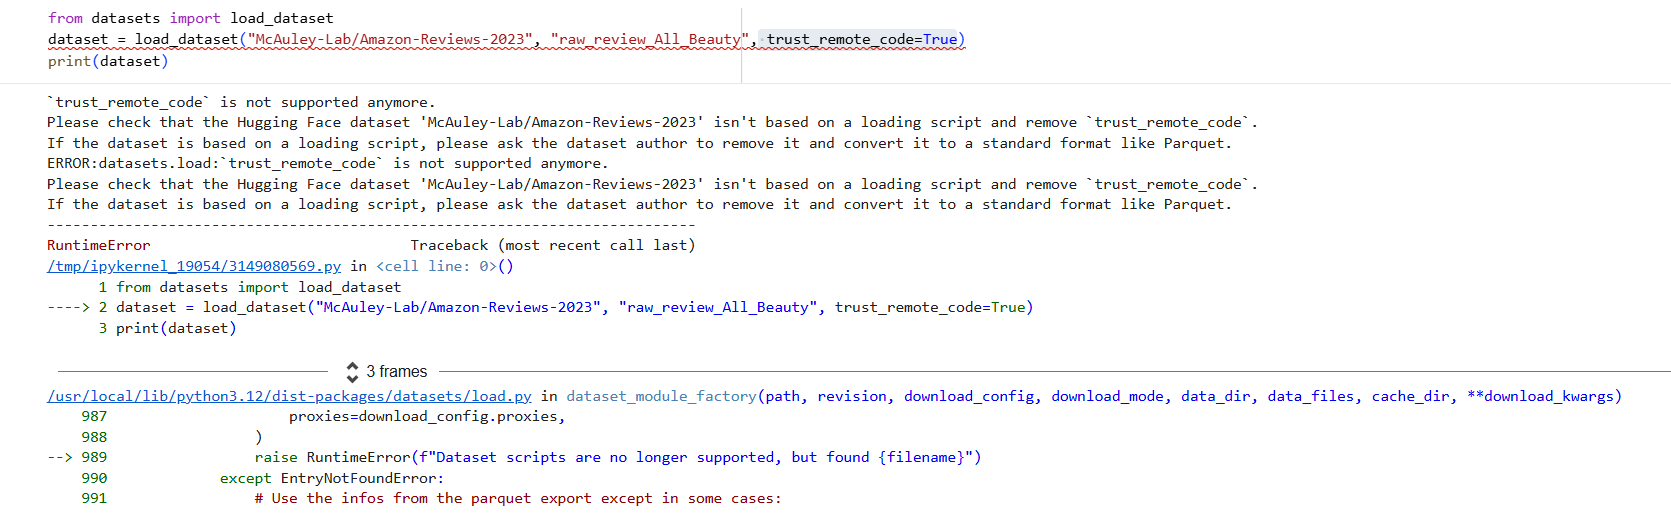

Successfully loading the dataset.

In [ ]:
from datasets import load_dataset
dataset = load_dataset("Yelp/yelp_review_full")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

Accessing the dataset for some basic EDA and filtering and indexing idea on the `dataset` object.

In [ ]:
dataset['train'][0]

{'label': 4,
 'text': "dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-notch hospital (nyu) which my parents have explained to me is very important in case something happens and you need surgery; and you can get referrals to see specialists without having to see him first.  really, what more do you need?  i'm sitting here trying to think of any complaints i have about him, but i'm really drawing a blank."}

In [ ]:
dataset['train'][0]['label']

4

In [ ]:
dataset['test'][1:11]['label']

[0, 0, 0, 0, 2, 1, 3, 3, 2, 1]

In [ ]:
dataset['test'][1:4]['text']

["Don't waste your time.  We had two different people come to our house to give us estimates for a deck (one of them the OWNER).  Both times, we never heard from them.  Not a call, not the estimate, nothing.",
 'All I can say is the worst! We were the only 2 people in the place for lunch, the place was freezing and loaded with kids toys! 2 bicycles, a scooter, and an electronic keyboard graced the dining room. A fish tank with filthy, slimy fingerprints smeared all over it is there for your enjoyment.\\n\\nOur food came... no water to drink, no tea, medium temperature food. Of course its cold, just like the room, I never took my jacket off! The plates are too small, you food spills over onto some semi-clean tables as you sit in your completely worn out booth seat. The fried noodles were out of a box and nasty, the shrimp was mushy, the fried rice was bright yellow.\\n\\nWe asked for water, they brought us 1 in a SOLO cup for 2 people. I asked for hot tea, they said 10 minutes. What Chi

```dataset``` is basically a dictionary with two dictionaries as objects, train and test.

Training dictionary consists of a list of samples (accessed through their index numbers), with list list elements being a dictionary with objects 'label' and 'text' as their keys.

Same goes for testing dictionary.

#**Plotting Vizualizations**

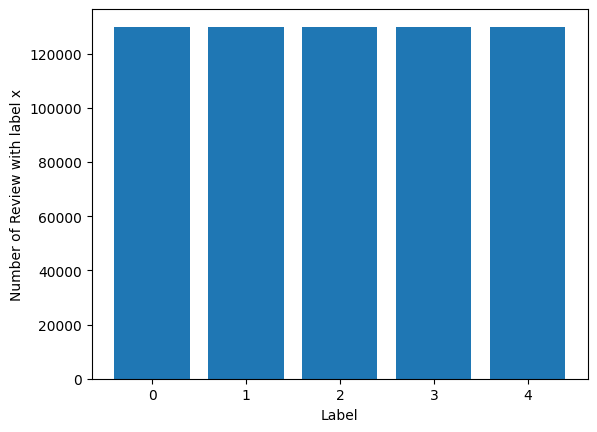

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame(dataset['train'])
df.head()
plt.bar(x=df['label'].unique(),height=df['label'].value_counts())
plt.xlabel("Label")
plt.ylabel("Number of Review with label x")
plt.show()

### **Class Distrubution**
The training set is perfectly balanced — 130,000 samples per class (5 classes). This means no class re-weighting or resampling is needed during training.

Mean no .of words in a review:  134.09808923076923
Min. no .of words in a review:  1
Max. no. of words in a review:  1052


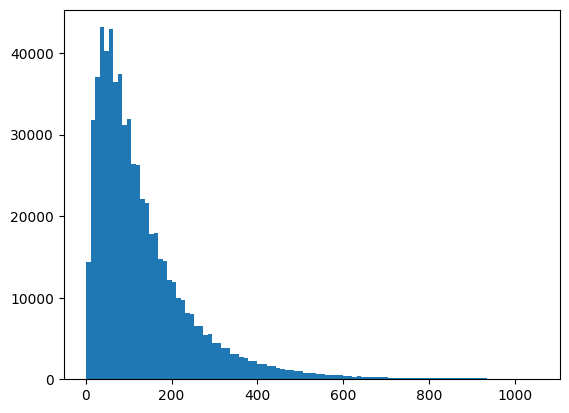

In [ ]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
print("Mean no .of words in a review: ",df['word_count'].mean())
print("Min. no .of words in a review: ",df['word_count'].min())
print("Max. no. of words in a review: ",df['word_count'].max())

plt.hist(df['word_count'], bins=100)
plt.show()

### **Review Length Distribution**
Review length is right-skewed — mean of 134 words, ranging from 1 to 1052. Most reviews fall under 200 words, with a long tail of longer outliers. This informed our choice of `max_len=200` for padding/truncation in the **LSTM pipeline** — long enough to capture most reviews fully, short enough to keep training efficient.